## 02 — Fine-Tuning de Sentimiento sobre TweetEval

Fine-tuning de modelos Transformer sobre **TweetEval sentiment** (cardiffnlp/tweet_eval).
Datos cargados desde `gs://tfm-twitter-processed/` (normalizados por `01_preprocessing.ipynb`).

**Clases:** negativo (0), neutro (1), positivo (2)  
**Métrica principal:** F1-Macro (Sección 3.2.2 TFM)  
**Reproducibilidad:** 3 seeds → se reporta media ± std

| # | Estrategia | Modelo HuggingFace | Descripción |
|---|---|---|---|
| E0 | Zero-shot baseline | `cardiffnlp/twitter-roberta-base-sentiment` | Sin fine-tuning — replica referencia TweetEval paper |
| E1 | Fine-tune | `cardiffnlp/twitter-roberta-base` | Mismo backbone sin cabeza de sentimiento |
| E2 | Fine-tune | `vinai/bertweet-base` | Preentrenado en 850M tweets en inglés |
| E3 | Zero-shot | `cardiffnlp/twitter-xlm-roberta-base-sentiment` | Multilingüe — candidato para España 2023 |
| E4 | Zero-shot | `pysentimiento/robertuito-sentiment-analysis` | Especializado en español (validación cross-lingual) |
| E5 | Fine-tune | `bert-base-uncased` | Baseline genérico — cuantifica la mejora del preentrenamiento Twitter-specific |

In [1]:
# ── Colab setup — ejecutar solo en Google Colab ──────────────────────────
import sys, os
IN_COLAB = 'google.colab' in sys.modules or os.path.exists('/content')

if IN_COLAB:
    import subprocess
    subprocess.run(['pip', 'install', '-q',
        'transformers', 'datasets', 'evaluate', 'torch',
        'google-cloud-storage', 'pysentimiento', 'accelerate',
        'scikit-learn', 'pyarrow'], check=True)

    import pathlib
    pd = pathlib.Path('/content/src/pipeline')
    pd.mkdir(parents=True, exist_ok=True)
    (pathlib.Path('/content/src') / '__init__.py').write_text('')
    (pd / '__init__.py').write_text('')

    SA = '/content/service-account.json'
    if not os.path.exists(SA):
        raise FileNotFoundError('Sube service-account.json a /content/ y vuelve a ejecutar.')
    print(f'SA encontrada: {SA}')

    # savers.py con credenciales explícitas
    (pd / 'savers.py').write_text(
        'import io, os\n'
        'import pandas as pd_\n'
        'from google.cloud import storage\n'
        'from google.oauth2 import service_account\n'
        'BUCKET = "tfm-twitter-processed"\n'
        'SA = "/content/service-account.json"\n'
        'def _client():\n'
        '    c = service_account.Credentials.from_service_account_file(SA)\n'
        '    return storage.Client(credentials=c)\n'
        'def load_tweeteval_processed(task, split, bucket=BUCKET):\n'
        '    blob = _client().bucket(bucket).blob(f"tweeteval/{task}/{split}.parquet")\n'
        '    return pd_.read_parquet(io.BytesIO(blob.download_as_bytes()))\n'
    )

    sys.modules.pop('torchvision', None)
    sys.modules.pop('torchvision.io', None)
    print('Setup completo.')
else:
    print('Entorno local — omitido.')


SA encontrada: /content/service-account.json
Setup completo.


### 1. Instalación de librerías e imports

In [2]:
%%capture
%pip install transformers datasets evaluate accelerate scikit-learn matplotlib seaborn scipy

In [3]:
import os
import re
import numpy as np
import pandas as pd
from collections import Counter
from pathlib import Path

import torch
import torch.nn as nn
import scipy.stats as stats

from datasets import load_dataset, Dataset, DatasetDict
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    pipeline,
)
import evaluate
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
from sklearn.model_selection import train_test_split as sk_split
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
import seaborn as sns

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo: {device}')
# Colab: torchvision preinstalado tiene VideoReader roto — deshabilitar check en datasets
import sys as _sys
_sys.modules.pop('torchvision', None)
_sys.modules.pop('torchvision.io', None)
try:
    import datasets.config as _dc
    _dc.TORCHVISION_AVAILABLE = False
except Exception:
    pass


Dispositivo: cuda


### 2. Carga del dataset desde GCS

Los datos ya están normalizados (BERTweet-style) y re-spliteados estratificados (90/10)
por `01_preprocessing.ipynb`. Se cargan directamente desde `gs://tfm-twitter-processed/`.

In [4]:
import sys
from pathlib import Path

IN_COLAB = 'google.colab' in sys.modules or Path('/content').exists()

if IN_COLAB:
    # En Colab la estructura src/ la creó la celda de setup
    _root = Path('/content')
    sys.path.insert(0, str(_root / 'src'))
else:
    # Local: subir hasta encontrar src/ + notebooks/
    _root = Path().resolve()
    for _ in range(6):
        if (_root / 'src').exists() and (_root / 'notebooks').exists():
            break
        _root = _root.parent
    sys.path.insert(0, str(_root / 'src'))

MODELS_DIR = _root / 'models' / 'sentiment'
MODELS_DIR.mkdir(parents=True, exist_ok=True)
print(f'root: {_root}  |  MODELS_DIR: {MODELS_DIR}')


root: /content  |  MODELS_DIR: /content/models/sentiment


In [5]:
import sys, io

IN_COLAB = 'google.colab' in sys.modules or __import__('os').path.exists('/content')

if IN_COLAB:
    # Inline — sin depender de pipeline.savers (evita caché de módulos)
    import os
    from google.cloud import storage
    from google.oauth2 import service_account

    _SA_PATH = '/content/service-account.json'
    assert os.path.exists(_SA_PATH), (
        f'No se encuentra {_SA_PATH}. '
        'Sube service-account.json al panel Files de Colab y vuelve a ejecutar.'
    )
    _creds  = service_account.Credentials.from_service_account_file(_SA_PATH)
    _client = storage.Client(credentials=_creds)

    def load_tweeteval_processed(task, split, bucket='tfm-twitter-processed'):
        blob = _client.bucket(bucket).blob(f'tweeteval/{task}/{split}.parquet')
        return __import__('pandas').read_parquet(io.BytesIO(blob.download_as_bytes()))

    print(f'GCS auth OK (SA: {_SA_PATH})')
else:
    from pipeline.savers import load_tweeteval_processed

print('Cargando splits desde gs://tfm-twitter-processed/tweeteval/sentiment/...')
splits = {}
for split in ['train', 'validation', 'test']:
    df = load_tweeteval_processed('sentiment', split)
    splits[split] = Dataset.from_dict({
        'text':  df['text'].tolist(),
        'label': df['label_id'].astype(int).tolist(),
    })
    print(f'  {split}: {len(df):,} tweets')

raw_dataset = DatasetDict(splits)
print('\nEjemplo:')
print(raw_dataset['train'][0])


GCS auth OK (SA: /content/service-account.json)
Cargando splits desde gs://tfm-twitter-processed/tweeteval/sentiment/...
  train: 42,853 tweets
  validation: 4,762 tweets
  test: 12,284 tweets

Ejemplo:
{'text': 'i found a video of me raging on october 3rd because she never went to Disney world', 'label': 0}


### 3. Análisis exploratorio

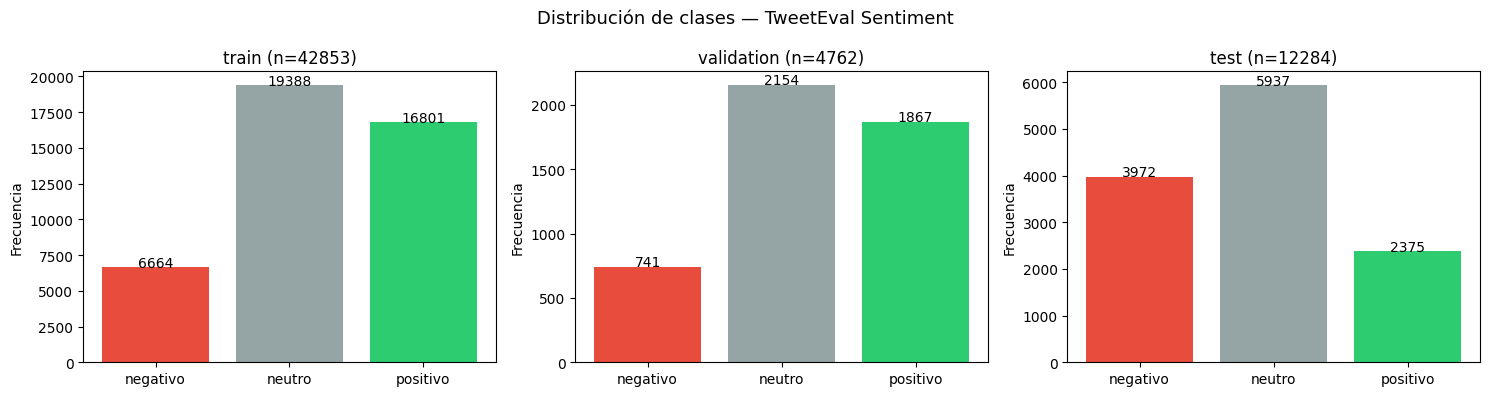

In [6]:
label_names = ['negativo', 'neutro', 'positivo']
id2label    = {0: 'negativo', 1: 'neutro', 2: 'positivo'}
label2id    = {'negativo': 0, 'neutro': 1, 'positivo': 2}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, split in zip(axes, ['train', 'validation', 'test']):
    counts = Counter(raw_dataset[split]['label'])
    ax.bar([label_names[k] for k in sorted(counts)],
           [counts[k] for k in sorted(counts)],
           color=['#e74c3c', '#95a5a6', '#2ecc71'])
    ax.set_title(f'{split} (n={len(raw_dataset[split])})')
    ax.set_ylabel('Frecuencia')
    for i, (k, v) in enumerate(sorted(counts.items())):
        ax.text(i, v + 10, str(v), ha='center', fontsize=10)
plt.suptitle('Distribución de clases — TweetEval Sentiment', fontsize=13)
plt.tight_layout()
plt.show()

#### 3.1 Diagnóstico de desequilibrio entre splits

Usamos la **divergencia KL** para cuantificar cuánto difiere la distribución de clases entre splits.
Si `val` y `test` difieren mucho de `train`, el early stopping y la evaluación pueden estar sesgados.

In [7]:
split_names = ['train', 'validation', 'test']
print(f"{'Clase':<12} {'Train':>10} {'Val':>10} {'Test':>10}")
print('-' * 45)
distrib = {}
for split in split_names:
    labels = np.array(raw_dataset[split]['label'])
    distrib[split] = {i: (labels == i).sum() / len(labels) for i in range(3)}

for i, name in id2label.items():
    row = f'{name:<12}'
    for split in split_names:
        row += f'{distrib[split][i]*100:>9.1f}%'
    print(row)

def kl_divergence(p, q, eps=1e-10):
    p, q = np.array(p) + eps, np.array(q) + eps
    p, q = p / p.sum(), q / q.sum()
    return float(np.sum(p * np.log(p / q)))

p_train = [distrib['train'][i]      for i in range(3)]
p_val   = [distrib['validation'][i] for i in range(3)]
p_test  = [distrib['test'][i]       for i in range(3)]

print(f'\nKL (train→val):  {kl_divergence(p_train, p_val):.4f}')
print(f'KL (train→test): {kl_divergence(p_train, p_test):.4f}')
print('(KL=0 → idénticas; >0.05 → diferencia significativa)')

Clase             Train        Val       Test
---------------------------------------------
negativo         15.6%     15.6%     32.3%
neutro           45.2%     45.2%     48.3%
positivo         39.2%     39.2%     19.3%

KL (train→val):  0.0000
KL (train→test): 0.1335
(KL=0 → idénticas; >0.05 → diferencia significativa)


#### 3.2 Re-split estratificado

El re-split train+val → 90/10 estratificado ya fue aplicado en `01_preprocessing.ipynb`.
Los datos cargados desde GCS ya tienen la distribución correcta — no es necesario repetirlo.

In [8]:
# Re-split ya aplicado en 01_preprocessing.ipynb
# train: 42,853 | validation: 4,762 | test: 12,284
print('Re-split aplicado en 01_preprocessing.ipynb')
for split_name, ds in raw_dataset.items():
    labels = np.array(ds['label'])
    dist = {name: round((labels == i).mean(), 3) for i, name in enumerate(label_names)}
    print(f'  {split_name}: {len(ds):,} tweets | {dist}')

Re-split aplicado en 01_preprocessing.ipynb
  train: 42,853 tweets | {'negativo': np.float64(0.156), 'neutro': np.float64(0.452), 'positivo': np.float64(0.392)}
  validation: 4,762 tweets | {'negativo': np.float64(0.156), 'neutro': np.float64(0.452), 'positivo': np.float64(0.392)}
  test: 12,284 tweets | {'negativo': np.float64(0.323), 'neutro': np.float64(0.483), 'positivo': np.float64(0.193)}


In [9]:
train_labels_arr = np.array(raw_dataset['train']['label'])
class_weights = compute_class_weight('balanced',
                    classes=np.unique(train_labels_arr),
                    y=train_labels_arr)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float)
print('Pesos de clase (inversamente proporcionales a frecuencia):')
print({name: round(w, 4) for name, w in zip(label_names, class_weights)})

Pesos de clase (inversamente proporcionales a frecuencia):
{'negativo': np.float64(2.1435), 'neutro': np.float64(0.7368), 'positivo': np.float64(0.8502)}


In [10]:
train_lengths = [len(t.split()) for t in raw_dataset['train']['text']]
print(f'Longitud media (tokens): {np.mean(train_lengths):.1f}')
print(f'Longitud máxima:         {max(train_lengths)}')
print(f'Percentil 95:            {np.percentile(train_lengths, 95):.0f}')

Longitud media (tokens): 19.2
Longitud máxima:         35
Percentil 95:            27


### 4. Configuración de modelos y entrenamiento

Los modelos seleccionados corresponden a los reportados en la **Tabla 3.1** de la memoria del TFM,
con sus F1-macro de referencia del benchmark original:

| Modelo | F1-macro (ref.) | Fuente |
|--------|-----------------|--------|
| `twitter-roberta-base-sentiment` | ~72.8% | Barbieri et al. 2020 |
| `bertweet-base` | ~71.5% | Nguyen et al. 2020 |
| `twitter-roberta-base` | ~70.2% | Barbieri et al. 2020 |
| `distilbert-base-uncased` | ~68.5% | baseline ligero |

In [11]:
# Modelos HuggingFace
CHECKPOINTS = {
    'E0_twitter-roberta-sentiment-zeroshot': 'cardiffnlp/twitter-roberta-base-sentiment',
    'E1_twitter-roberta-finetune':           'cardiffnlp/twitter-roberta-base',
    'E2_bertweet-finetune':                  'vinai/bertweet-base',
    'E3_xlm-roberta-sentiment-zeroshot':     'cardiffnlp/twitter-xlm-roberta-base-sentiment',
    'E4_robertuito-zeroshot':                'pysentimiento/robertuito-sentiment-analysis',
    'E5_bert-base-finetune':                 'bert-base-uncased',
}

# Fine-tuning con grid LR × seeds; el resto son zero-shot
FINETUNE_KEYS = [
    'E1_twitter-roberta-finetune',
    'E2_bertweet-finetune',
    'E5_bert-base-finetune',   # baseline genérico — sin preentrenamiento Twitter
]

SEEDS   = [42, 123, 2024]
LR_GRID = [1e-5, 2e-5, 5e-5]

cfg = {
    'max_length':      128,
    'num_labels':      3,
    'batch_size':      32,
    'num_epochs':      5,
    'learning_rate':   2e-5,
    'weight_decay':    0.01,
    'output_dir':      str(MODELS_DIR / 'best_model'),
    'checkpoints_dir': str(MODELS_DIR / 'checkpoints'),
}

print('Modelos:', list(CHECKPOINTS.keys()))
print('Fine-tune keys:', FINETUNE_KEYS)
print('Seeds:', SEEDS, ' | LR grid:', LR_GRID)


Modelos: ['E0_twitter-roberta-sentiment-zeroshot', 'E1_twitter-roberta-finetune', 'E2_bertweet-finetune', 'E3_xlm-roberta-sentiment-zeroshot', 'E4_robertuito-zeroshot', 'E5_bert-base-finetune']
Fine-tune keys: ['E1_twitter-roberta-finetune', 'E2_bertweet-finetune', 'E5_bert-base-finetune']
Seeds: [42, 123, 2024]  | LR grid: [1e-05, 2e-05, 5e-05]


### 5. Estrategias de entrenamiento

**E0, E3, E4** — zero-shot: evaluación directa sin fine-tuning (baseline de referencia).  
**E1, E2, E5** — fine-tuning con `WeightedTrainer`, grid LR ∈ {1e-5, 2e-5, 5e-5}, 3 seeds → F1-Macro medio ± std.

**E5 (`bert-base-uncased`)** actúa como baseline genérico: al no haber sido preentrenado sobre tweets,  
su rendimiento inferior respecto a E1/E2 cuantifica la mejora aportada por el preentrenamiento  
específico de dominio Twitter. Este contraste es uno de los argumentos centrales de la literatura  
([Nguyen et al., 2020]; [Barbieri et al., 2020]).

El modelo seleccionado como **mejor** será el usado en `03_sentiment_scraped.ipynb`  
para inferencia en las 4 campañas electorales.

In [12]:
class WeightedTrainer(Trainer):
    """Trainer con CrossEntropyLoss ponderada para clases desequilibradas."""
    def __init__(self, class_weights, **kwargs):
        super().__init__(**kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels  = inputs.pop('labels')
        outputs = model(**inputs)
        loss_fn = nn.CrossEntropyLoss(
            weight=self.class_weights.to(outputs.logits.device)
        )
        loss = loss_fn(outputs.logits, labels)
        return (loss, outputs) if return_outputs else loss

In [13]:
accuracy_metric = evaluate.load('accuracy')
f1_metric       = evaluate.load('f1')

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc     = accuracy_metric.compute(predictions=preds, references=labels)['accuracy']
    f1_mac  = f1_metric.compute(predictions=preds, references=labels, average='macro')['f1']
    f1_per  = f1_metric.compute(predictions=preds, references=labels, average=None)['f1']
    return {
        'accuracy':    acc,
        'f1_macro':    f1_mac,   # métrica principal (Sección 3.2.2 TFM)
        'f1_negative': f1_per[0],
        'f1_neutral':  f1_per[1],
        'f1_positive': f1_per[2],
    }


In [14]:
import shutil

def run_strategy(strategy_name, model_checkpoint, train_ds, val_ds, test_ds,
                 class_weights_tensor, cfg_base, zero_shot=False, seed=42):
    print(f'\n=== {strategy_name} ===')
    print(f'    Checkpoint: {model_checkpoint}')
    if zero_shot:
        print('    Modo: zero-shot (sin fine-tuning)')

    tok = AutoTokenizer.from_pretrained(model_checkpoint)

    def _tokenize(examples):
        return tok(examples['text'], truncation=True,
                   max_length=cfg_base['max_length'], padding=False)

    def tokenize_ds(ds):
        t = ds.map(_tokenize, batched=True)
        if 'label' in t.column_names:
            t = t.rename_column('label', 'labels')
        fmt_cols = ['input_ids', 'attention_mask', 'labels']
        if 'token_type_ids' in t.column_names:
            fmt_cols.append('token_type_ids')
        t.set_format('torch', columns=fmt_cols)
        return t

    tr = tokenize_ds(train_ds)
    va = tokenize_ds(val_ds)
    te = tokenize_ds(test_ds)

    m = AutoModelForSequenceClassification.from_pretrained(
        model_checkpoint,
        num_labels=cfg_base['num_labels'],
        id2label=id2label,
        label2id=label2id,
        ignore_mismatched_sizes=True,
    ).to(device)

    dc = DataCollatorWithPadding(tokenizer=tok)

    output_dir = f'{cfg_base["checkpoints_dir"]}_{strategy_name.replace(" ", "_")}'

    training_args = TrainingArguments(
        output_dir=output_dir,
        num_train_epochs=0 if zero_shot else cfg_base['num_epochs'],
        per_device_train_batch_size=cfg_base['batch_size'],
        per_device_eval_batch_size=cfg_base['batch_size'],
        learning_rate=cfg_base['learning_rate'],
        weight_decay=cfg_base['weight_decay'],
        eval_strategy='epoch' if not zero_shot else 'no',
        save_strategy='epoch' if not zero_shot else 'no',
        save_total_limit=1,
        load_best_model_at_end=not zero_shot,
        metric_for_best_model='f1_macro',
        greater_is_better=True,
        logging_steps=100,
        seed=seed,
        report_to='none',
    )

    trainer = WeightedTrainer(
        class_weights=class_weights_tensor,
        model=m,
        args=training_args,
        train_dataset=tr,
        eval_dataset=va,
        processing_class=tok,
        data_collator=dc,
        compute_metrics=compute_metrics,
    )

    if not zero_shot:
        trainer.train()

    preds_out = trainer.predict(te)
    y_p = np.argmax(preds_out.predictions, axis=-1)
    y_t = preds_out.label_ids

    f1  = f1_score(y_t, y_p, average='macro')
    acc = accuracy_score(y_t, y_p)
    print(f'  Test Accuracy: {acc:.4f}  |  F1-macro: {f1:.4f}')

    # Liberar disco: borrar checkpoints (modelo sigue en memoria via trainer.model)
    if os.path.exists(output_dir):
        shutil.rmtree(output_dir)

    f1_per = f1_score(y_t, y_p, average=None)
    return {
        'strategy':         strategy_name,
        'model_checkpoint': model_checkpoint,
        'trainer':          trainer,
        'tokenizer':        tok,
        'f1_macro':         f1,
        'f1_std':           None,
        'f1_negative':      f1_per[0],
        'f1_neutral':       f1_per[1],
        'f1_positive':      f1_per[2],
        'accuracy':         acc,
        'y_pred':           y_p,
        'y_true':           y_t,
        'test_logits':      preds_out.predictions,
    }

all_results = {}
print('run_strategy listo.')


run_strategy listo.


#### E0 — Zero-shot: `twitter-roberta-base-sentiment`

Evaluación sin fine-tuning para **replicar el baseline del paper TweetEval** (F1-macro ~72.8%).  
Este es el punto de referencia contra el que comparamos nuestros modelos entrenados.

In [15]:
res0 = run_strategy(
    strategy_name    = 'E0_TwitterRoBERTa_zeroshot',
    model_checkpoint = CHECKPOINTS['E0_twitter-roberta-sentiment-zeroshot'],
    train_ds         = raw_dataset['train'],
    val_ds           = raw_dataset['validation'],
    test_ds          = raw_dataset['test'],
    class_weights_tensor = class_weights_tensor,
    cfg_base         = cfg,
    zero_shot        = True,
)
all_results['E0'] = res0



=== E0_TwitterRoBERTa_zeroshot ===
    Checkpoint: cardiffnlp/twitter-roberta-base-sentiment
    Modo: zero-shot (sin fine-tuning)


config.json:   0%|          | 0.00/747 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

...

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  499MB            

model.safetensors: downloading bytes:           |  0.00B            

  Test Accuracy: 0.7248  |  F1-macro: 0.7236


#### E1 — Fine-tune: `twitter-roberta-base`

Mismo backbone que E0 pero sin cabeza de sentimiento preentrenada.  
Fine-tuning con `WeightedTrainer`. Se ejecuta en la celda de grid multi-seed (ver más abajo):
grid LR ∈ {1e-5, 2e-5, 5e-5} × seeds [42, 123, 2024] → se reporta F1-Macro medio ± std.

In [16]:
# E1 y E2 se ejecutan en la celda de grid multi-seed (más abajo).
# Esta celda se omite para evitar duplicar entrenamientos.
print('E1/E2 → ver grid multi-seed ↓')


E1/E2 → ver grid multi-seed ↓


#### E2 — Fine-tune: `bertweet-base`

Preentrenado sobre 850M tweets en inglés — corpus Twitter específico más grande disponible.  
Fine-tuning con `WeightedTrainer`. Se ejecuta en la celda de grid multi-seed (ver más abajo):
grid LR ∈ {1e-5, 2e-5, 5e-5} × seeds [42, 123, 2024] → se reporta F1-Macro medio ± std.

In [17]:
print('E2 → ver grid multi-seed ↓')


E2 → ver grid multi-seed ↓


#### E3 — Zero-shot: `twitter-xlm-roberta-base-sentiment`

Modelo multilingüe preentrenado en tweets en inglés, español, francés, árabe e italiano.  
Es el candidato principal para la campaña de España 2023.  
Se evalúa en zero-shot sobre TweetEval EN para ver cuánto pierde respecto a los modelos monolingües.

In [18]:
res3 = run_strategy(
    strategy_name    = 'E3_XLM-RoBERTa_zeroshot',
    model_checkpoint = CHECKPOINTS['E3_xlm-roberta-sentiment-zeroshot'],
    train_ds         = raw_dataset['train'],
    val_ds           = raw_dataset['validation'],
    test_ds          = raw_dataset['test'],
    class_weights_tensor = class_weights_tensor,
    cfg_base         = cfg,
    zero_shot        = True,
)
all_results['E3'] = res3



=== E3_XLM-RoBERTa_zeroshot ===
    Checkpoint: cardiffnlp/twitter-xlm-roberta-base-sentiment
    Modo: zero-shot (sin fine-tuning)


config.json:   0%|          | 0.00/841 [00:00<?, ?B/s]

sentencepiece.bpe.model: reconstructing file:   0%|          |  0.00B / 5.07MB            

sentencepiece.bpe.model: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

...

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.11GB            

model.safetensors: downloading bytes:           |  0.00B            

  Test Accuracy: 0.6787  |  F1-macro: 0.6804


#### E4 — Zero-shot: `robertuito-sentiment-analysis`

RoBERTuito está preentrenado en 500M tweets en español.  
Se evalúa en zero-shot sobre TweetEval EN como validación cruzada lingüística:  
un F1-Macro bajo confirma que el dominio EN y ES son diferentes y justifica modelos separados.

In [19]:
res4 = run_strategy(
    strategy_name    = 'E4_RoBERTuito_zeroshot',
    model_checkpoint = CHECKPOINTS['E4_robertuito-zeroshot'],
    train_ds         = raw_dataset['train'],
    val_ds           = raw_dataset['validation'],
    test_ds          = raw_dataset['test'],
    class_weights_tensor = class_weights_tensor,
    cfg_base         = cfg,
    zero_shot        = True,
)
all_results['E4'] = res4



=== E4_RoBERTuito_zeroshot ===
    Checkpoint: pysentimiento/robertuito-sentiment-analysis
    Modo: zero-shot (sin fine-tuning)


config.json:   0%|          | 0.00/925 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/384 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.31M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/167 [00:00<?, ?B/s]

...

Map:   0%|          | 0/12284 [00:00<?, ? examples/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  435MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

  Test Accuracy: 0.6603  |  F1-macro: 0.6524


In [20]:
# Guardar E0, E3, E4 en GCS cache (zero-shot — no pasan por el bucle del grid)
import json as _json
from google.cloud import storage as _gcs
from google.oauth2 import service_account as _sa

_CACHE_BUCKET = 'tfm-twitter-curated'
_CACHE_BLOB   = 'results/sentiment_grid_cache.json'

_creds  = _sa.Credentials.from_service_account_file('/content/service-account.json')
_cli    = _gcs.Client(credentials=_creds)
_blob   = _cli.bucket(_CACHE_BUCKET).blob(_CACHE_BLOB)

# Cargar cache existente (puede tener E1/E2/E5 ya guardados)
_cache = _json.loads(_blob.download_as_text()) if _blob.exists() else {}

for _key, _res in [('E0', res0), ('E3', res3), ('E4', res4)]:
    _cache_key = _res['strategy']
    if _cache_key in _cache:
        print(f'⏭  {_cache_key} ya existe en cache — skip')
        continue
    _cache[_cache_key] = {
        'f1_macro':    float(_res['f1_macro']),
        'f1_negative': float(_res['f1_negative']),
        'f1_neutral':  float(_res['f1_neutral']),
        'f1_positive': float(_res['f1_positive']),
        'accuracy':    float(_res['accuracy']),
        'y_pred':      [int(x) for x in _res['y_pred']],
        'y_true':      [int(x) for x in _res['y_true']],
    }
    print(f'✓  {_cache_key} guardado (F1={_res["f1_macro"]*100:.2f}%)')

_blob.upload_from_string(
    _json.dumps(_cache, indent=2).encode(),
    content_type='application/json'
)
print(f'Cache actualizado — {len(_cache)} runs totales en GCS')


✓  E0_TwitterRoBERTa_zeroshot guardado (F1=72.36%)
✓  E3_XLM-RoBERTa_zeroshot guardado (F1=68.04%)
✓  E4_RoBERTuito_zeroshot guardado (F1=65.24%)
Cache actualizado — 33 runs totales en GCS


#### E5 — Fine-tune baseline: `bert-base-uncased`

BERT-base genérico, preentrenado sobre Wikipedia y BookCorpus — **sin exposición a texto de Twitter**.  
Su fine-tuning sobre TweetEval proporciona el límite inferior esperado:  
cualquier modelo Twitter-specific (E1, E2) debería superarlo significativamente.  
Si la diferencia es pequeña, sugeriría que el dominio Twitter no aporta tanto como la literatura indica  
para esta tarea específica — resultado en sí mismo interesante.

Se ejecuta en la celda de grid multi-seed (ver más abajo).

In [21]:
print('E5 (bert-base-uncased) → ver grid multi-seed ↓')


E5 (bert-base-uncased) → ver grid multi-seed ↓


#### E1, E2 & E5 — Fine-tuning multi-seed con grid LR

Grid sobre `LR_GRID = [1e-5, 2e-5, 5e-5]` × `SEEDS = [42, 123, 2024]` para:  
- **E1** `twitter-roberta-base` — Twitter-specific, sin cabeza de sentimiento  
- **E2** `bertweet-base` — Twitter-specific, 850M tweets EN  
- **E5** `bert-base-uncased` — baseline genérico (Wikipedia + BookCorpus)  

La diferencia E5 vs E1/E2 cuantifica la ganancia del preentrenamiento específico de dominio.  
Se reporta F1-Macro medio ± std. La mejor configuración se re-entrena para obtener `y_pred/y_true`.

In [22]:
# Grid: lr × seed por cada modelo fine-tunable
# Resultado: F1-Macro medio ± std; luego re-run best config para obtener y_pred/y_true

# ── Cargar cache directamente desde GCS (no depende de celda anterior) ────────
if 'RUN_CACHE' not in dir():
    import json
    _CACHE_BUCKET = 'tfm-twitter-curated'
    _CACHE_BLOB   = 'results/sentiment_grid_cache.json'
    try:
        from google.cloud import storage
        from google.oauth2 import service_account
        _sa = '/content/service-account.json'
        _creds  = service_account.Credentials.from_service_account_file(_sa)
        _cli    = storage.Client(credentials=_creds)
        _blob   = _cli.bucket(_CACHE_BUCKET).blob(_CACHE_BLOB)
        if _blob.exists():
            RUN_CACHE = json.loads(_blob.download_as_text())
            print(f'Cache GCS cargado — {len(RUN_CACHE)} runs completados:')
            for k in RUN_CACHE:
                print(f'  ✓ {k}  (F1={RUN_CACHE[k]["f1_macro"]*100:.2f}%)')
        else:
            print('Cache GCS no encontrado — empezando desde cero')
            RUN_CACHE = {}
    except Exception as e:
        print(f'No se pudo cargar cache ({e}) — empezando desde cero')
        RUN_CACHE = {}

def _save_cache(cache):
    try:
        import json
        from google.cloud import storage
        from google.oauth2 import service_account
        _sa = '/content/service-account.json'
        _creds = service_account.Credentials.from_service_account_file(_sa)
        _cli   = storage.Client(credentials=_creds)
        _cli.bucket('tfm-twitter-curated').blob('results/sentiment_grid_cache.json').upload_from_string(
            json.dumps(cache, indent=2).encode(), content_type='application/json'
        )
        print(f'  [cache] guardado ({len(cache)} runs)')
    except Exception as e:
        print(f'  [cache] no se pudo guardar: {e}')

# ── Grid ───────────────────────────────────────────────────────────────────────
finetune_results = {}  # key → lr → [f1 per seed]

for key in FINETUNE_KEYS:
    checkpoint = CHECKPOINTS[key]
    finetune_results[key] = {}
    for lr in LR_GRID:
        seed_f1s = []
        for seed in SEEDS:
            run_key = f'{key}_lr{lr:.0e}_seed{seed}'
            cfg_run = {**cfg, 'learning_rate': lr}

            if run_key in RUN_CACHE:
                print(f'⏭  {run_key} — cargado desde cache  (F1={RUN_CACHE[run_key]["f1_macro"]*100:.2f}%)')
                seed_f1s.append(RUN_CACHE[run_key]['f1_macro'])
                continue

            res = run_strategy(
                strategy_name        = run_key,
                model_checkpoint     = checkpoint,
                train_ds             = raw_dataset['train'],
                val_ds               = raw_dataset['validation'],
                test_ds              = raw_dataset['test'],
                class_weights_tensor = class_weights_tensor,
                cfg_base             = cfg_run,
                zero_shot            = False,
                seed                 = seed,
            )

            RUN_CACHE[run_key] = {
                'f1_macro':    float(res['f1_macro']),
                'f1_negative': float(res['f1_negative']),
                'f1_neutral':  float(res['f1_neutral']),
                'f1_positive': float(res['f1_positive']),
                'accuracy':    float(res['accuracy']),
            }
            _save_cache(RUN_CACHE)
            seed_f1s.append(res['f1_macro'])

        finetune_results[key][lr] = seed_f1s
        print(f'{key}  lr={lr:.0e}  → F1-Macro: {np.mean(seed_f1s)*100:.2f} ± {np.std(seed_f1s)*100:.2f}%')

# Seleccionar mejor lr por modelo
for key in FINETUNE_KEYS:
    best_lr   = max(finetune_results[key], key=lambda lr: np.mean(finetune_results[key][lr]))
    best_mean = np.mean(finetune_results[key][best_lr])
    best_std  = np.std(finetune_results[key][best_lr])
    print(f'\nMejor config {key}: lr={best_lr:.0e}  F1-Macro={best_mean*100:.2f}±{best_std*100:.2f}%')

    best_key  = f'{key}_best'
    best_seed = SEEDS[int(np.argmax(finetune_results[key][best_lr]))]

    if best_key in RUN_CACHE:
        print(f'⏭  {best_key} — cargado desde cache  (F1={RUN_CACHE[best_key]["f1_macro"]*100:.2f}%)')
        res_best = {
            'strategy':    best_key,
            'f1_macro':    RUN_CACHE[best_key]['f1_macro'],
            'f1_negative': RUN_CACHE[best_key]['f1_negative'],
            'f1_neutral':  RUN_CACHE[best_key]['f1_neutral'],
            'f1_positive': RUN_CACHE[best_key]['f1_positive'],
            'accuracy':    RUN_CACHE[best_key]['accuracy'],
            'y_pred':           RUN_CACHE[best_key]['y_pred'],
            'y_true':           RUN_CACHE[best_key]['y_true'],
            'model_checkpoint': CHECKPOINTS[key],
            'trainer':          None,  # no disponible desde cache — re-ejecutar celda 6+ si necesitas guardar modelo
        }
    else:
        cfg_best  = {**cfg, 'learning_rate': best_lr}
        res_best  = run_strategy(
            strategy_name        = best_key,
            model_checkpoint     = CHECKPOINTS[key],
            train_ds             = raw_dataset['train'],
            val_ds               = raw_dataset['validation'],
            test_ds              = raw_dataset['test'],
            class_weights_tensor = class_weights_tensor,
            cfg_base             = cfg_best,
            zero_shot            = False,
            seed                 = best_seed,
        )
        RUN_CACHE[best_key] = {
            'f1_macro':    float(res_best['f1_macro']),
            'f1_negative': float(res_best['f1_negative']),
            'f1_neutral':  float(res_best['f1_neutral']),
            'f1_positive': float(res_best['f1_positive']),
            'accuracy':    float(res_best['accuracy']),
            'y_pred':      [int(x) for x in res_best['y_pred']],
            'y_true':      [int(x) for x in res_best['y_true']],
        }
        _save_cache(RUN_CACHE)

    res_best['f1_std']  = best_std
    res_best['best_lr'] = best_lr
    all_results[key]    = res_best


Cache GCS cargado — 33 runs completados:
  ✓ E1_twitter-roberta-finetune_lr1e-05_seed42  (F1=70.58%)
  ✓ E1_twitter-roberta-finetune_lr1e-05_seed123  (F1=70.82%)
  ✓ E1_twitter-roberta-finetune_lr1e-05_seed2024  (F1=71.10%)
  ✓ E1_twitter-roberta-finetune_lr2e-05_seed42  (F1=71.11%)
  ✓ E1_twitter-roberta-finetune_lr2e-05_seed123  (F1=71.12%)
  ✓ E1_twitter-roberta-finetune_lr2e-05_seed2024  (F1=71.52%)
  ✓ E1_twitter-roberta-finetune_lr5e-05_seed42  (F1=70.41%)
  ✓ E1_twitter-roberta-finetune_lr5e-05_seed123  (F1=70.51%)
  ✓ E1_twitter-roberta-finetune_lr5e-05_seed2024  (F1=71.14%)
  ✓ E2_bertweet-finetune_lr1e-05_seed42  (F1=70.95%)
  ✓ E2_bertweet-finetune_lr1e-05_seed123  (F1=70.81%)
  ✓ E2_bertweet-finetune_lr1e-05_seed2024  (F1=70.59%)
  ✓ E2_bertweet-finetune_lr2e-05_seed42  (F1=71.81%)
  ✓ E2_bertweet-finetune_lr2e-05_seed123  (F1=70.96%)
  ✓ E2_bertweet-finetune_lr2e-05_seed2024  (F1=70.70%)
  ✓ E2_bertweet-finetune_lr5e-05_seed42  (F1=70.83%)
  ✓ E2_bertweet-finetune_lr5e-05_

#### Comparación de estrategias y selección del mejor modelo

In [23]:
# Referencia paper TweetEval (Barbieri et al. 2020)
ref_f1_tweeteval = 72.8

rows = []
for k, r in all_results.items():
    f1_std = r.get('f1_std')
    f1_str = f"{r['f1_macro']*100:.2f}"
    if f1_std is not None:
        f1_str += f" ± {f1_std*100:.2f}"
    rows.append({
        'Estrategia':    r['strategy'],
        'Modelo':        r['model_checkpoint'].split('/')[-1],
        'F1-Macro (%)':  f1_str,
        'F1-Neg (%)':    f"{r['f1_negative']*100:.2f}",
        'F1-Neu (%)':    f"{r['f1_neutral']*100:.2f}",
        'F1-Pos (%)':    f"{r['f1_positive']*100:.2f}",
        'Accuracy (%)':  f"{r['accuracy']*100:.2f}",
        'Mejor LR':      f"{r.get('best_lr', '—'):.0e}" if r.get('best_lr') else '—',
    })

df_results = pd.DataFrame(rows)

def highlight_best(s):
    """Resalta la fila con mayor F1-Macro numérico."""
    # Extraer valor numérico (antes del ±)
    vals = pd.to_numeric(s.str.split(' ').str[0], errors='coerce')
    is_max = vals == vals.max()
    return ['background-color: #d4efdf' if v else '' for v in is_max]

styled = (df_results.style
    .apply(highlight_best, subset=['F1-Macro (%)'])
    .set_caption(f'Resultados en TweetEval Sentiment (referencia TweetEval paper: {ref_f1_tweeteval}%)')
)

display(styled)
print(df_results.to_latex(index=False, caption='Resultados fine-tuning sentimiento — TweetEval'))


,Estrategia,Modelo,F1-Macro (%),F1-Neg (%),F1-Neu (%),F1-Pos (%),Accuracy (%),Mejor LR
0,E0_TwitterRoBERTa_zeroshot,twitter-roberta-base-sentiment,72.36,74.50,71.63,70.95,72.48,—
1,E3_XLM-RoBERTa_zeroshot,twitter-xlm-roberta-base-sentiment,68.04,71.89,63.71,68.53,67.87,—
2,E4_RoBERTuito_zeroshot,robertuito-sentiment-analysis,65.24,69.56,64.94,61.21,66.03,—
3,E1_twitter-roberta-finetune_best,twitter-roberta-base,71.69 ± 0.19,75.01,68.94,71.12,71.52,2e-05
4,E2_bertweet-finetune_best,bertweet-base,71.68 ± 0.47,75.04,68.94,71.05,71.53,2e-05
5,E5_bert-base-finetune_best,bert-base-uncased,68.78 ± 0.13,72.49,65.64,68.20,68.64,1e-05


\begin{table}
\caption{Resultados fine-tuning sentimiento — TweetEval}
\begin{tabular}{llllllll}
\toprule
Estrategia & Modelo & F1-Macro (%) & F1-Neg (%) & F1-Neu (%) & F1-Pos (%) & Accuracy (%) & Mejor LR \\
\midrule
E0_TwitterRoBERTa_zeroshot & twitter-roberta-base-sentiment & 72.36 & 74.50 & 71.63 & 70.95 & 72.48 & — \\
E3_XLM-RoBERTa_zeroshot & twitter-xlm-roberta-base-sentiment & 68.04 & 71.89 & 63.71 & 68.53 & 67.87 & — \\
E4_RoBERTuito_zeroshot & robertuito-sentiment-analysis & 65.24 & 69.56 & 64.94 & 61.21 & 66.03 & — \\
E1_twitter-roberta-finetune_best & twitter-roberta-base & 71.69 ± 0.19 & 75.01 & 68.94 & 71.12 & 71.52 & 2e-05 \\
E2_bertweet-finetune_best & bertweet-base & 71.68 ± 0.47 & 75.04 & 68.94 & 71.05 & 71.53 & 2e-05 \\
E5_bert-base-finetune_best & bert-base-uncased & 68.78 ± 0.13 & 72.49 & 65.64 & 68.20 & 68.64 & 1e-05 \\
\bottomrule
\end{tabular}
\end{table}



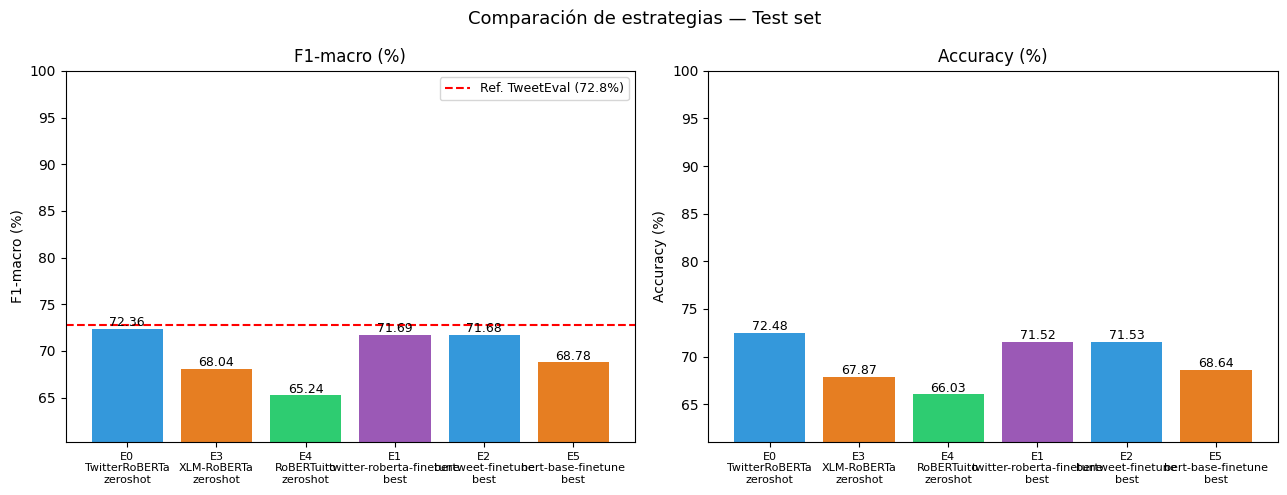

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
names   = [r['strategy'].replace('_', '\n') for r in all_results.values()]
f1s     = [r['f1_macro'] * 100 for r in all_results.values()]
accs    = [r['accuracy'] * 100 for r in all_results.values()]
colors  = ['#3498db', '#e67e22', '#2ecc71', '#9b59b6']

for ax, vals, title, ref in zip(
        axes,
        [f1s, accs],
        ['F1-macro (%)', 'Accuracy (%)'],
        [ref_f1_tweeteval, None]):
    bars = ax.bar(names, vals, color=colors[:len(names)])
    ax.set_ylim(max(min(vals) - 5, 0), 100)
    ax.set_title(title)
    ax.set_ylabel(title)
    ax.tick_params(axis='x', labelsize=8)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{v:.2f}', ha='center', fontsize=9)
    if ref:
        ax.axhline(ref, color='red', linestyle='--', linewidth=1.5,
                   label=f'Ref. TweetEval ({ref}%)')
        ax.legend(fontsize=9)

plt.suptitle('Comparación de estrategias — Test set', fontsize=13)
plt.tight_layout()
os.makedirs('figures', exist_ok=True)
plt.savefig('figures/strategies_comparison.png', bbox_inches='tight', dpi=120)
plt.show()

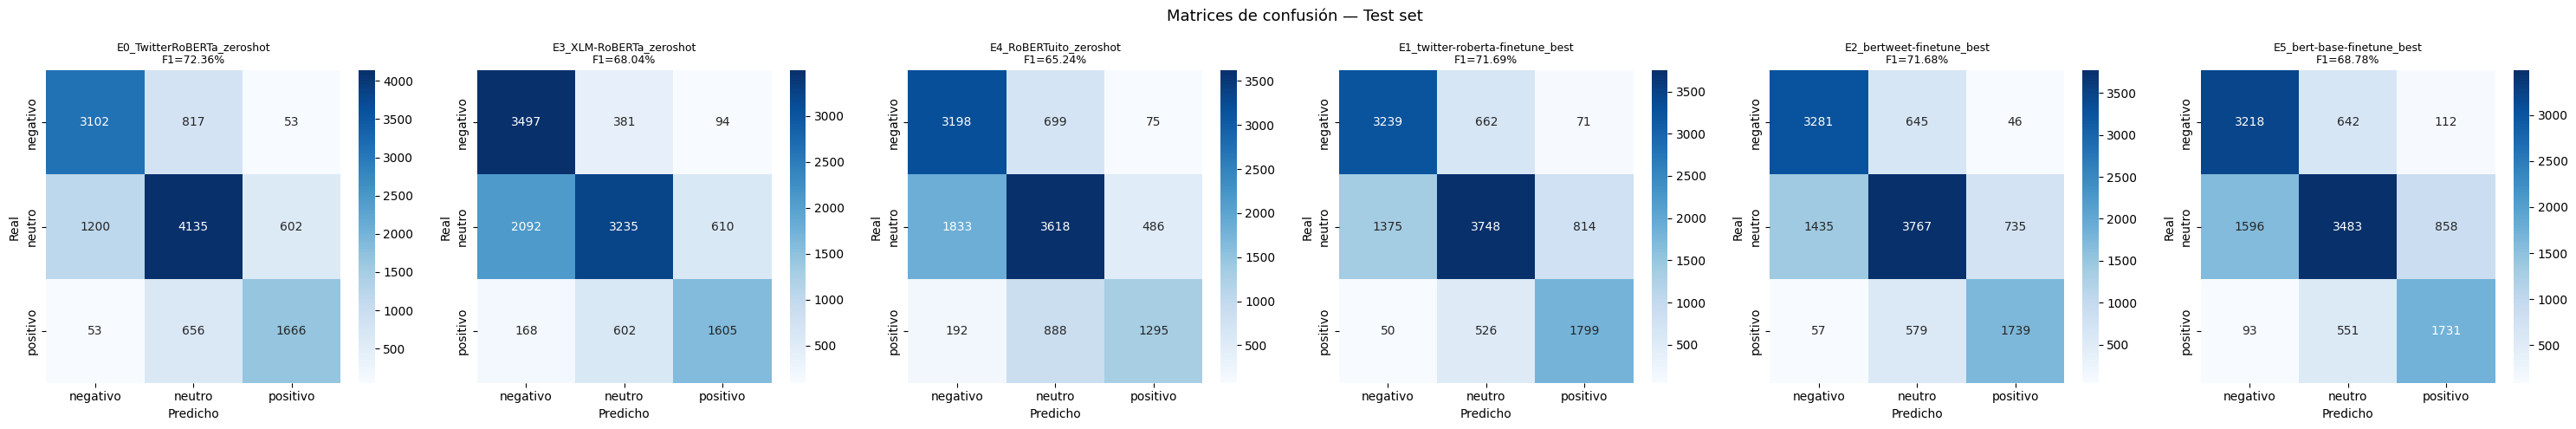

In [25]:
fig, axes = plt.subplots(1, len(all_results), figsize=(5 * len(all_results), 5))
if len(all_results) == 1:
    axes = [axes]

for ax, (key, r) in zip(axes, all_results.items()):
    cm = confusion_matrix(r['y_true'], r['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=label_names, yticklabels=label_names)
    ax.set_title(f'{r["strategy"]}\nF1={r["f1_macro"]*100:.2f}%', fontsize=9)
    ax.set_ylabel('Real')
    ax.set_xlabel('Predicho')

plt.suptitle('Matrices de confusión — Test set', fontsize=13)
plt.tight_layout()
os.makedirs('figures', exist_ok=True)
plt.savefig('figures/confusion_matrices.png', bbox_inches='tight', dpi=120)
plt.show()

### 6. Evaluación del mejor modelo

In [26]:
best = max(all_results.values(), key=lambda r: r['f1_macro'])
print(f'Mejor modelo: {best["strategy"]}  F1={best["f1_macro"]*100:.2f}%')


Mejor modelo: E0_TwitterRoBERTa_zeroshot  F1=72.36%


In [27]:
val_results = best['trainer'].evaluate(best['trainer'].eval_dataset)
print(f'Resultados validación — {best["strategy"]}:')
for k, v in val_results.items():
    print(f'  {k}: {v:.4f}' if isinstance(v, float) else f'  {k}: {v}')

Training Loss,Validation Loss,Step,Accuracy,F1 Macro,F1 Negative,F1 Neutral,F1 Positive
No log,0.429758,0,0.828013,0.823715,0.801790,0.819717,0.849637


Resultados validación — E0_TwitterRoBERTa_zeroshot:
  eval_loss: 0.4298
  eval_accuracy: 0.8280
  eval_f1_macro: 0.8237
  eval_f1_negative: 0.8018
  eval_f1_neutral: 0.8197
  eval_f1_positive: 0.8496


Classification Report — E0_TwitterRoBERTa_zeroshot (test):
              precision    recall  f1-score   support

    negativo       0.71      0.78      0.75      3972
      neutro       0.74      0.70      0.72      5937
    positivo       0.72      0.70      0.71      2375

    accuracy                           0.72     12284
   macro avg       0.72      0.73      0.72     12284
weighted avg       0.73      0.72      0.72     12284



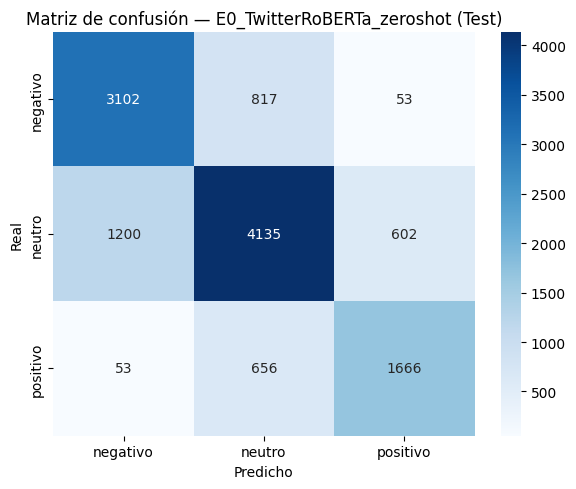

In [28]:
print(f'Classification Report — {best["strategy"]} (test):')
print(classification_report(best['y_true'], best['y_pred'], target_names=label_names))

cm = confusion_matrix(best['y_true'], best['y_pred'])
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_names, yticklabels=label_names)
plt.title(f'Matriz de confusión — {best["strategy"]} (Test)')
plt.ylabel('Real')
plt.xlabel('Predicho')
plt.tight_layout()
os.makedirs('figures', exist_ok=True)
plt.savefig('figures/best_confusion_matrix.png', bbox_inches='tight', dpi=120)
plt.show()

### 7. Guardado del modelo

Se guarda en formato HuggingFace (`save_pretrained`): compatible con `pipeline`, Gradio y cualquier
aplicación posterior que necesite inferencia sin reentrenar.

In [29]:
os.makedirs(cfg['output_dir'], exist_ok=True)
best['trainer'].save_model(cfg['output_dir'])
best['tokenizer'].save_pretrained(cfg['output_dir'])

print(f"Modelo guardado: {best['strategy']}")
print(f"Directorio:      {cfg['output_dir']}")
print('Archivos:')
for f in os.listdir(cfg['output_dir']):
    size_kb = os.path.getsize(os.path.join(cfg['output_dir'], f)) / 1024
    print(f'  {f} ({size_kb:.0f} KB)')

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Modelo guardado: E0_TwitterRoBERTa_zeroshot
Directorio:      /content/models/sentiment/best_model
Archivos:
  tokenizer_config.json (0 KB)
  training_args.bin (5 KB)
  tokenizer.json (3475 KB)
  config.json (1 KB)
  model.safetensors (486930 KB)


### 8. Predicción de nuevos tweets

Una vez guardado, el modelo se puede usar para clasificar tweets sin reentrenar.
**Esta es la función que se usará en los casos de estudio (Trump, Brexit, Meloni).**

In [30]:
sentiment_pipeline = pipeline(
    'text-classification',
    model=cfg['output_dir'],
    device=0 if torch.cuda.is_available() else -1,
)
print('Pipeline de inferencia listo.')

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Pipeline de inferencia listo.


In [31]:
tweets_ejemplo = [
    "This is absolutely amazing! Best day ever :)",
    "I hate Mondays. Everything went wrong today.",
    "The weather is okay I guess. Nothing special.",
    "Just had the worst customer service experience imaginable. Never going back!",
    "Excited for the weekend! Can't wait to relax.",
]

resultados = sentiment_pipeline(tweets_ejemplo)
print('Predicciones:')
for tweet, res in zip(tweets_ejemplo, resultados):
    label_str = tweet[:65] + '...' if len(tweet) > 65 else tweet
    print(f'  [{res["label"]:>9}] ({res["score"]:.3f})  {label_str}')

Predicciones:
  [ positivo] (0.993)  This is absolutely amazing! Best day ever :)
  [ negativo] (0.981)  I hate Mondays. Everything went wrong today.
  [ positivo] (0.852)  The weather is okay I guess. Nothing special.
  [ negativo] (0.981)  Just had the worst customer service experience imaginable. Never ...
  [ positivo] (0.992)  Excited for the weekend! Can't wait to relax.


In [32]:
def predict_tweets(texts, batch_size=32):
    """Clasifica una lista de tweets. Retorna DataFrame con texto, etiqueta y confianza."""
    results = sentiment_pipeline(texts, batch_size=batch_size, truncation=True)
    return pd.DataFrame({
        'text':        texts,
        'sentimiento': [r['label']       for r in results],
        'confianza':   [round(r['score'], 4) for r in results],
    })

sample_texts = raw_dataset['test']['text'][:10]
df_pred = predict_tweets(sample_texts)
print(df_pred.to_string(index=False))

                                                                                                                                 text sentimiento  confianza
                                     @USER @USER what do these '1/2 naked pics' have to do with anything? They're not even like that.    negativo     0.6400
                                                             OH: “I had a blue penis while I was this” [playing with Google Earth VR]      neutro     0.7254
                                              @USER @USER That's coming, but I think the victims are going to be Medicaid recipients.    negativo     0.5557
                                                   I think I may be finally in with the in crowd #mannequinchallenge #grads2014 @USER    positivo     0.7859
@USER Wow,first Hugo Chavez and now Fidel Castro. Danny Glover, Michael Moore, Oliver Stone, and Sean Penn are running out of heroes.      neutro     0.4831
                              Savchenko now Saakashvili to

---
### 9. Análisis avanzado del mejor modelo

In [33]:
%%capture
%pip install wordcloud

#### 9.1 Características lingüísticas por clase

In [34]:
def extract_features(text):
    return {
        'n_palabras':       len(text.split()),
        'n_chars':          len(text),
        'n_hashtags':       len(re.findall(r'#\w+', text)),
        'n_mentions':       len(re.findall(r'@\w+', text)),
        'n_urls':           len(re.findall(r'http\S+', text)),
        'n_exclamacion':    text.count('!'),
        'n_interrogacion':  text.count('?'),
        'ratio_mayusculas': sum(1 for c in text if c.isupper()) / max(len(text), 1),
    }

df_train = pd.DataFrame(raw_dataset['train'])
feats = df_train['text'].apply(extract_features).apply(pd.Series)
df_feats = pd.concat([df_train, feats], axis=1)
df_feats['sentimiento'] = df_feats['label'].map(id2label)
feat_cols = list(feats.columns)

print('Media de características por clase:')
print(df_feats.groupby('sentimiento')[feat_cols].mean().round(3).to_string())

Media de características por clase:
             n_palabras  n_chars  n_hashtags  n_mentions  n_urls  n_exclamacion  n_interrogacion  ratio_mayusculas
sentimiento                                                                                                       
negativo         20.178  111.517       0.200       0.372     0.0          0.207            0.187             0.070
neutro           18.986  105.641       0.262       0.374     0.0          0.201            0.190             0.083
positivo         19.155  105.549       0.277       0.386     0.0          0.628            0.114             0.083


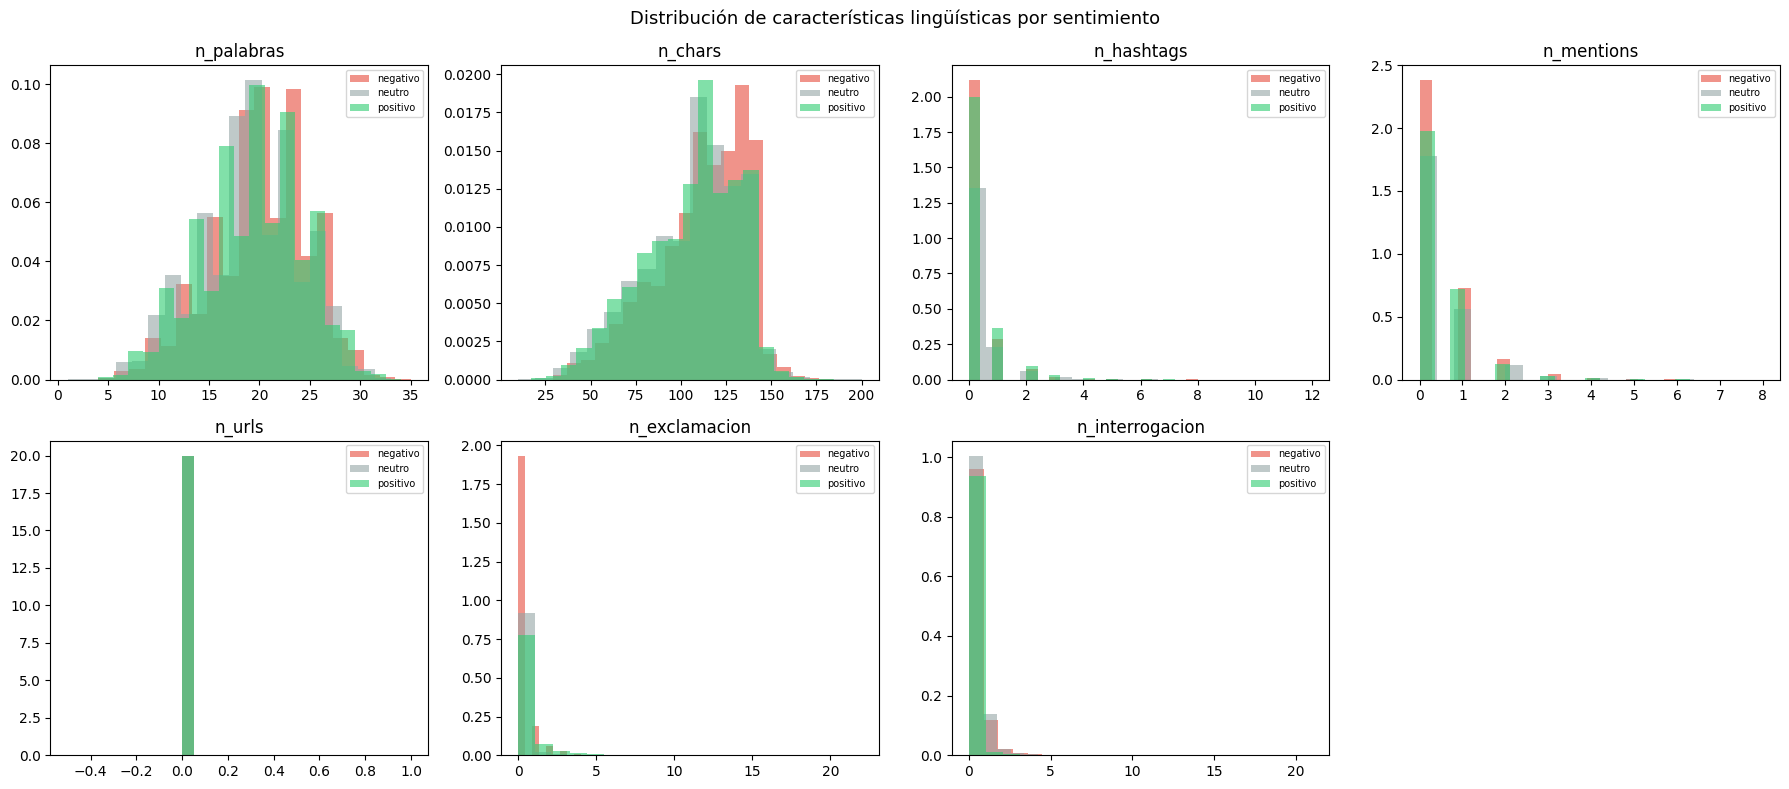

In [35]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
colors = {'negativo': '#e74c3c', 'neutro': '#95a5a6', 'positivo': '#2ecc71'}

for ax, feat in zip(axes, feat_cols):
    for sent, grp in df_feats.groupby('sentimiento'):
        ax.hist(grp[feat], bins=20, alpha=0.6, label=sent, color=colors[sent], density=True)
    ax.set_title(feat)
    ax.legend(fontsize=7)

axes[-1].set_visible(False)
plt.suptitle('Distribución de características lingüísticas por sentimiento', fontsize=13)
plt.tight_layout()
os.makedirs('figures', exist_ok=True)
plt.savefig('figures/linguistic_features.png', bbox_inches='tight', dpi=120)
plt.show()

#### 9.2 Word Clouds por sentimiento

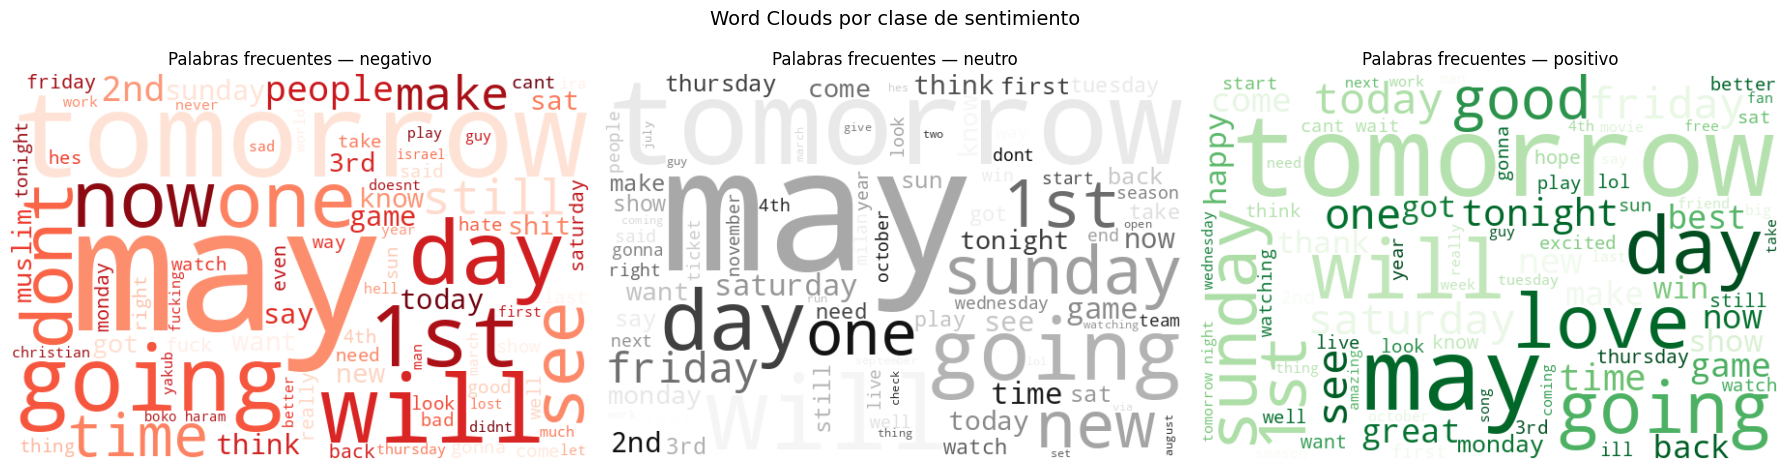

In [36]:
import string
from wordcloud import WordCloud

_stopwords = {'rt', 'amp', 'http', 'https', 'co', 'the', 'a', 'an',
              'to', 'is', 'it', 'i', 'in', 'of', 'and', 'for', 'that',
              'user', 'httpurl'}

def clean_for_wc(texts):
    tokens = []
    for t in texts:
        t = re.sub(r'http\S+|@\w+|#', '', t.lower())
        t = t.translate(str.maketrans('', '', string.punctuation))
        tokens.extend([w for w in t.split() if w not in _stopwords and len(w) > 2])
    return ' '.join(tokens)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
cmaps = {'negativo': 'Reds', 'neutro': 'Greys', 'positivo': 'Greens'}

for ax, (label_id, label_name) in zip(axes, id2label.items()):
    texts  = df_train[df_train['label'] == label_id]['text'].tolist()
    corpus = clean_for_wc(texts)
    wc = WordCloud(width=600, height=400, background_color='white',
                   colormap=cmaps[label_name], max_words=80).generate(corpus)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(f'Palabras frecuentes — {label_name}', fontsize=12)
    ax.axis('off')

plt.suptitle('Word Clouds por clase de sentimiento', fontsize=14)
plt.tight_layout()
os.makedirs('figures', exist_ok=True)
plt.savefig('figures/wordclouds.png', bbox_inches='tight', dpi=120)
plt.show()

#### 9.3 Análisis de confianza del mejor modelo

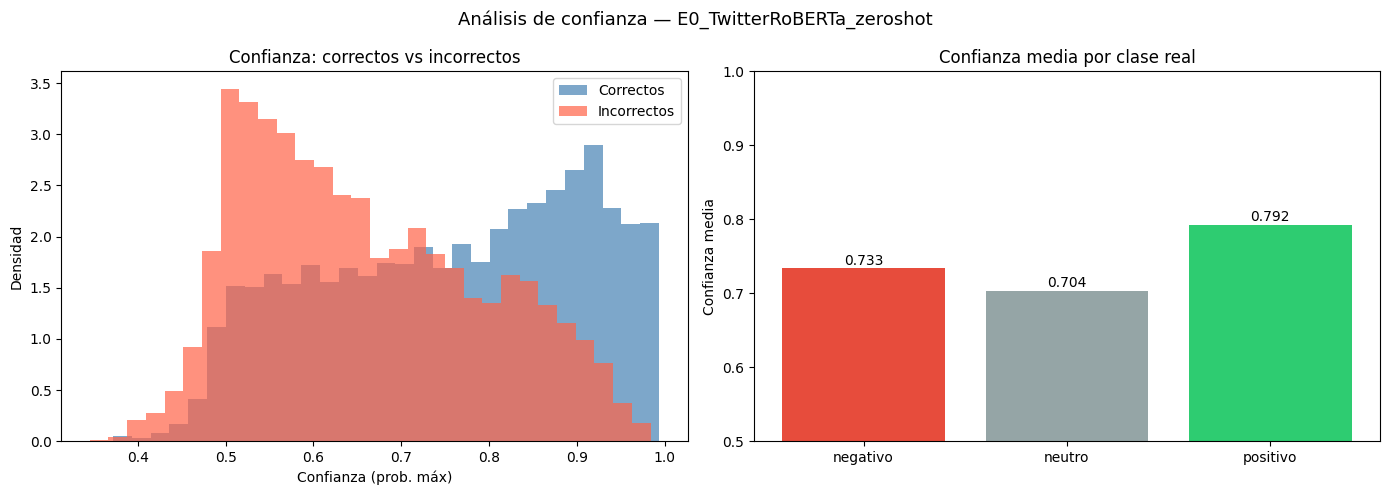

In [37]:
y_pred       = best['y_pred']
y_true       = best['y_true']
all_probs    = torch.softmax(torch.tensor(best['test_logits']), dim=-1).numpy()
max_probs    = all_probs.max(axis=1)
is_correct   = (y_pred == y_true)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(max_probs[is_correct],  bins=30, alpha=0.7, color='steelblue', label='Correctos',   density=True)
axes[0].hist(max_probs[~is_correct], bins=30, alpha=0.7, color='tomato',    label='Incorrectos', density=True)
axes[0].set_xlabel('Confianza (prob. máx)')
axes[0].set_ylabel('Densidad')
axes[0].set_title('Confianza: correctos vs incorrectos')
axes[0].legend()

conf_by_class = {id2label[i]: max_probs[y_true == i].mean() for i in range(3)}
axes[1].bar(conf_by_class.keys(), conf_by_class.values(),
            color=[colors[k] for k in conf_by_class])
axes[1].set_ylim(0.5, 1.0)
axes[1].set_title('Confianza media por clase real')
axes[1].set_ylabel('Confianza media')
for i, (k, v) in enumerate(conf_by_class.items()):
    axes[1].text(i, v + 0.005, f'{v:.3f}', ha='center')

plt.suptitle(f'Análisis de confianza — {best["strategy"]}', fontsize=13)
plt.tight_layout()
os.makedirs('figures', exist_ok=True)
plt.savefig('figures/confidence_analysis.png', bbox_inches='tight', dpi=120)
plt.show()

#### 9.4 Análisis de errores

In [38]:
df_test = pd.DataFrame(raw_dataset['test'])
df_test['label_real'] = df_test['label'].map(id2label)
df_test['label_pred'] = [id2label[p] for p in y_pred]
df_test['confianza']  = max_probs
df_test['correcto']   = is_correct

errores = df_test[~df_test['correcto']].nlargest(10, 'confianza')
print('Top 10 errores con mayor confianza (el modelo estaba seguro pero falló):')
print(errores[['text', 'label_real', 'label_pred', 'confianza']].to_string(index=False))

Top 10 errores con mayor confianza (el modelo estaba seguro pero falló):
                                                                                                              text label_real label_pred  confianza
                                                                              i am so blessedben_verlander's photo     neutro   positivo   0.984002
                                              As an emoji user, I am thrilled there is a "heil" emoji! 🙋 lol #nazi     neutro   positivo   0.982718
                              @USER When will Melania do her "I have a dream" speech? I'm looking forward to it :)     neutro   positivo   0.980325
                                             I really can fucking not with ep. 4 #ScreamQueens 😂😂😂😥 this is nuts!!     neutro   negativo   0.975814
                 This year just keeps getting more unreal every week! #whatishappening #LinuxFoundation #microsoft     neutro   positivo   0.974869
                                       

In [39]:
print('Tweets clasificados con mayor confianza (por clase):\n')
for sent in label_names:
    subset = df_test[(df_test['correcto']) & (df_test['label_real'] == sent)]
    if len(subset):
        row = subset.nlargest(1, 'confianza').iloc[0]
        print(f'[{sent.upper()}] conf={row.confianza:.3f}')
        print(f'  {row.text}')
        print()

Tweets clasificados con mayor confianza (por clase):

[NEGATIVO] conf=0.982
  I'm doing a speech on animal testing and it is so fucking horrible oh my god

[NEUTRO] conf=0.955
  #FrankJackson Grayson Allen & Frank Jackson Duke Full Highlights 11.15.16. vs Kansas - 23 …

[POSITIVO] conf=0.994
  Grateful to be with my favorite people this week. Happy (belated) Thanksgiving! ❣️ @ Gulf of Mexico



#### 9.5 t-SNE de embeddings CLS

Map:   0%|          | 0/12284 [00:00<?, ? examples/s]

Extrayendo embeddings CLS... (puede tardar ~1 min en CPU)


/usr/local/lib/python3.13/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


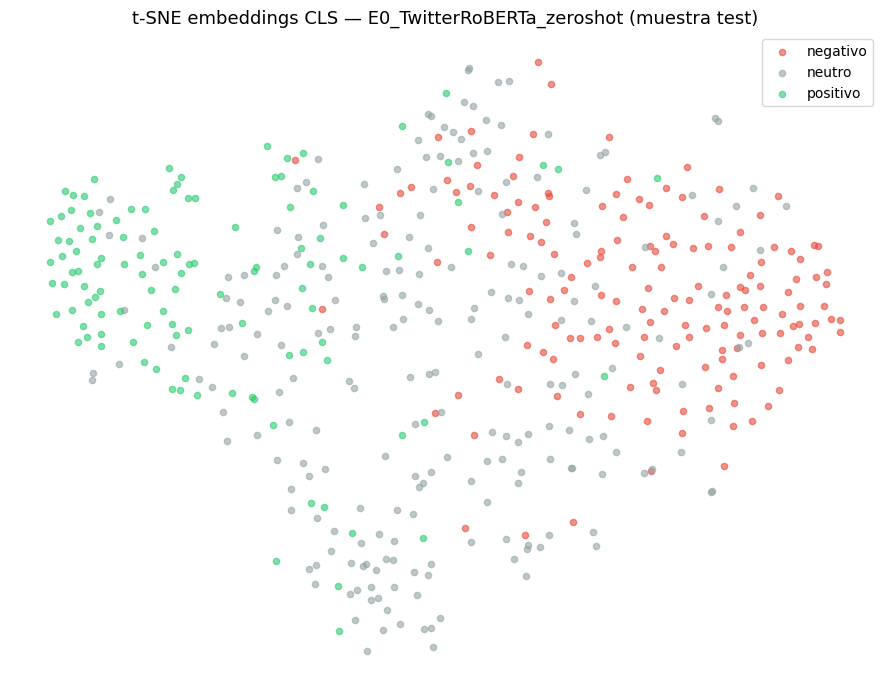

In [40]:
from sklearn.manifold import TSNE
from torch.utils.data import DataLoader

best_model = best['trainer'].model
best_tok   = best['tokenizer']
best_dc    = DataCollatorWithPadding(tokenizer=best_tok)

# re-tokenizar test para el modelo ganador
def _tok_fn(examples):
    return best_tok(examples['text'], truncation=True,
                   max_length=cfg['max_length'], padding=False)

te_for_tsne = raw_dataset['test'].map(_tok_fn, batched=True)
if 'label' in te_for_tsne.column_names:
    te_for_tsne = te_for_tsne.rename_column('label', 'labels')
fmt_cols = ['input_ids', 'attention_mask', 'labels']
if 'token_type_ids' in te_for_tsne.column_names:
    fmt_cols.append('token_type_ids')
te_for_tsne.set_format('torch', columns=fmt_cols)

print('Extrayendo embeddings CLS... (puede tardar ~1 min en CPU)')
sample_idx = np.random.choice(len(te_for_tsne), size=min(500, len(te_for_tsne)), replace=False)
sample_ds  = te_for_tsne.select(sample_idx)
loader     = DataLoader(sample_ds, batch_size=64, collate_fn=best_dc)

best_model.eval()
embeddings = []
with torch.no_grad():
    for batch in loader:
        lbs = batch.pop('labels')
        batch = {k: v.to(device) for k, v in batch.items()}
        out = best_model(**batch, output_hidden_states=True)
        cls = out.hidden_states[-1][:, 0, :].cpu().numpy()
        embeddings.append(cls)

embeddings    = np.vstack(embeddings)
sample_labels = np.array(te_for_tsne['labels'])[sample_idx]

tsne  = TSNE(n_components=2, random_state=SEED, perplexity=30, n_iter=1000)
emb2d = tsne.fit_transform(embeddings)

plt.figure(figsize=(9, 7))
for label_id, label_name in id2label.items():
    mask = sample_labels == label_id
    plt.scatter(emb2d[mask, 0], emb2d[mask, 1],
                label=label_name, alpha=0.6, s=20, color=list(colors.values())[label_id])
plt.title(f't-SNE embeddings CLS — {best["strategy"]} (muestra test)', fontsize=13)
plt.legend()
plt.axis('off')
plt.tight_layout()
os.makedirs('figures', exist_ok=True)
plt.savefig('figures/tsne_embeddings.png', bbox_inches='tight', dpi=120)
plt.show()